## 1. Load & Inspect the Dataset

We load `psa_dataset_dholuo_somali.csv` and check its basic shape and health:
row/column counts, missing values, duplicates, and domain balance. This tells
us what preprocessing decisions are actually needed for this dataset, rather
than assuming the same issues Ekegusii had.

In [26]:
import pandas as pd

df = pd.read_csv("../data/processed/psa_dataset_dholuo_somali.csv", encoding="utf-8")

# Basic shape
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# Missing values per column
print("\nMissing values:\n", df.isnull().sum())

# Duplicates
print("\nFully duplicate rows:", df.duplicated().sum())
print("Duplicate Dholuo strings:", df["Dholuo"].duplicated().sum())
print("Duplicate Somali strings:", df["Somali"].duplicated().sum())

# Domain balance
print("\nDomain counts:\n", df["Domain"].value_counts())

# Class / Source breakdown
print("\nClass counts:\n", df["Class"].value_counts())
print("\nSource counts:\n", df["Source"].value_counts())

df.head(3)

Shape: (16029, 8)

Columns: ['PSA_Id', 'Domain', 'English', 'Kiswahili', 'Dholuo', 'Somali', 'Class', 'Source']

Missing values:
 PSA_Id       0
Domain       0
English      0
Kiswahili    0
Dholuo       0
Somali       1
Class        0
Source       0
dtype: int64

Fully duplicate rows: 0
Duplicate Dholuo strings: 27
Duplicate Somali strings: 21

Domain counts:
 Domain
Health               3764
Agriculture          3645
Education            2844
Governance           2748
Security             1795
Security & Safety    1233
Name: count, dtype: int64

Class counts:
 Class
General    10917
PSA         5112
Name: count, dtype: int64

Source counts:
 Source
grounded_generated           10917
original_baseline_dataset     5112
Name: count, dtype: int64


,PSA_Id,Domain,English,Kiswahili,Dholuo,Somali,Class,Source
0,1,Education,Comprehensive COVID-19 health and safety proto...,Itifaki kamili za afya na usalama za COVID-19 ...,Chenro mag thieth: Chenro mag thieth kod ritru...,Barnaamijyada caafimaadka iyo amniga ee COVID-...,PSA,original_baseline_dataset
1,2,Education,Digital learning platform providing free educa...,Jukwaa la kujifunza kidijitali linalotoa maudh...,Kenya Education Cloud: Ohinga mar somo mar dij...,Barashada dhijitaalka ah ee bixisa waxyaabaha ...,PSA,original_baseline_dataset
2,3,Education,KUCCPS portal will open in March 2025 for univ...,Lango la KUCCPS litafunguliwa Machi 2025 kwa n...,KUCCPS Portal: KUCCPS portal biro yawore e dwe...,Gudaha KUCCPS waxaa la furi doonaa bishii Maar...,PSA,original_baseline_dataset


In [27]:
missing_row = df[df["Somali"].isna()]
print(missing_row[["PSA_Id", "English","Kiswahili"]])  # see which row it is 

      PSA_Id                                            English  \
4888    4889  Citizens who understand accessing government s...   

                                              Kiswahili  
4888  Wananchi wanaoelewa kupata huduma za serikali ...  


## Interpretation: Initial Inspection

- **Size:** 16,029 rows across 8 columns (PSA_Id, Domain, English, Kiswahili,
  Dholuo, Somali, Class, Source).
- **Missing values:** Only 1 row (PSA_Id 4889, "Citizens who understand
  accessing government s...") is missing a Somali translation, out of
  16,029 — a negligible gap (0.006%), traced to a single failed request in
  the machine-translation script. Documented as an accepted, known minor
  gap rather than silently dropped.
- **Duplicates:** No fully duplicate rows. 27 duplicate Dholuo strings and
  21 duplicate Somali strings exist — worth a closer look in the next pass
  to confirm these are legitimate (e.g. reused short PSA phrases) rather
  than translation shortcuts, the way Ekegusii's notebook found for its
  own duplicates.
- **Domain balance:** Health (3,764) and Agriculture (3,645) are the
  largest domains; Education (2,844) and Governance (2,748) are mid-sized;
  Security and Security & Safety appear as two separate categories
  totaling 1,795 + 1,233 — this needs a team decision on whether to merge
  them, since it affects the true domain balance picture.
- **Class/Source:** 10,917 rows are grounded_generated (Class=General),
  5,112 are original_baseline_dataset (Class=PSA) — a roughly 2:1 synthetic-
  to-original ratio, consistent with the dataset's stated construction.

## 2. Quantifying Orthographic & Encoding Issues

Before normalizing anything, we count known issue types across English,
Kiswahili, Dholuo, and Somali columns: mojibake (encoding corruption),
smart-quote/apostrophe variants, and stray bracket artifacts. Dholuo uses
apostrophes for specific phonemes (e.g. ng'), so we check apostrophe
*variants* (straight vs curly), not apostrophes themselves, since removing
them incorrectly would damage real orthography.

In [28]:
import re

def count_pattern(df, cols, pattern, label):
    print(f"\n--- {label} ---")
    for col in cols:
        matches = df[col].astype(str).str.contains(pattern, regex=True, na=False)
        print(f"{col}: {matches.sum()} rows")

text_cols = ["English", "Kiswahili", "Dholuo", "Somali"]

# Mojibake — classic UTF-8/Windows-1252 double-encoding markers
count_pattern(df, text_cols, r"Â|â€|Ã©|Ã¢", "Mojibake indicators")

# Smart quote variants (curly quotes/apostrophes)
count_pattern(df, text_cols, r"[’‘“”]", "Curly quote/apostrophe variants")

# Straight apostrophe count for comparison (expected/legitimate in Dholuo, e.g. ng')
count_pattern(df, text_cols, r"'", "Straight apostrophes")

# Stray brackets / leftover markup artifacts
count_pattern(df, text_cols, r"[\[\]{}]", "Stray brackets")

# Double spaces / leading-trailing whitespace
count_pattern(df, text_cols, r"  +", "Double+ spaces")
whitespace_issues = df[text_cols].apply(lambda col: col.astype(str).str.strip() != col.astype(str))
print("\n--- Leading/trailing whitespace ---")
print(whitespace_issues.sum())


--- Mojibake indicators ---
English: 5 rows
Kiswahili: 7 rows
Dholuo: 0 rows
Somali: 2 rows

--- Curly quote/apostrophe variants ---
English: 0 rows
Kiswahili: 0 rows
Dholuo: 8215 rows
Somali: 264 rows

--- Straight apostrophes ---
English: 3446 rows
Kiswahili: 117 rows
Dholuo: 2768 rows
Somali: 2498 rows

--- Stray brackets ---
English: 8 rows
Kiswahili: 8 rows
Dholuo: 9 rows
Somali: 8 rows

--- Double+ spaces ---
English: 0 rows
Kiswahili: 0 rows
Dholuo: 0 rows
Somali: 0 rows

--- Leading/trailing whitespace ---
English      0
Kiswahili    0
Dholuo       0
Somali       0
dtype: int64


## Interpretation: Orthographic Noise

- **Mojibake:** Minimal across the board — English (5), Kiswahili (7),
  Somali (2), Dholuo (0). Not a significant issue for this dataset; the
  multi-pass ftfy pipeline Ekegusii needed is likely overkill here. A
  single light pass or even manual spot-check of these 14 rows is
  sufficient.
- **Curly quote/apostrophe variants:** This is the dataset's real finding.
  Dholuo has 8,215 rows (over half the dataset) with curly apostrophes/
  quotes, and Somali has 264. English and Kiswahili have zero. This
  strongly suggests the Dholuo column was passed through a process (likely
  MT or copy-paste from a formatted source) that converted straight
  apostrophes into typographic/curly ones inconsistently.
- **Straight apostrophes:** Present across all four columns (English 3,446;
  Dholuo 2,768; Somali 2,498; Kiswahili 117), meaning Dholuo currently has
  a *mix* of both curly and straight apostrophe styles for what should be
  the same linguistic feature — likely the ng' consonant marker and
  similar orthographic apostrophes. This is inconsistency, not necessarily
  incorrect content.
- **Stray brackets:** Minor and roughly even across columns (8-9 rows
  each) — likely leftover scraping artifacts, low priority.
- **Decision:** Standardize all curly apostrophe/quote variants (’ ‘ “ ”)
  to their straight equivalents (' ") across all four text columns, so
  that Dholuo's orthographic apostrophe usage (e.g. ng') is represented
  consistently rather than split across two visually different but
  linguistically identical characters. This is a normalization
  (consistency) fix, not a content removal — the apostrophes themselves
  are correct Dholuo orthography and must be preserved, only their
  character encoding is being standardized.

## 3. Normalizing Curly Apostrophes & Quotes

We standardize curly apostrophe/quote variants (’ ‘ “ ”) to their straight
ASCII equivalents (' ") across all four text columns. This is a
consistency fix, not a content change — Dholuo's orthographic apostrophe
usage (e.g. ng') is preserved, only the character encoding is unified so
the same linguistic feature isn't split across two different-looking
characters.


In [29]:
# Mapping of curly variants to their straight equivalents
quote_map = {
    "’": "'",
    "‘": "'",
    "“": '"',
    "”": '"',
}

def normalize_quotes(text):
    if pd.isna(text):
        return text
    for curly, straight in quote_map.items():
        text = text.replace(curly, straight)
    return text

# Apply to all four text columns
before_counts = {}
for col in text_cols:
    before_counts[col] = df[col].astype(str).str.contains(r"[’‘“”]", regex=True, na=False).sum()
    df[col] = df[col].apply(normalize_quotes)

# Confirm the fix worked
print("Before -> After curly quote/apostrophe counts:")
for col in text_cols:
    after = df[col].astype(str).str.contains(r"[’‘“”]", regex=True, na=False).sum()
    print(f"{col}: {before_counts[col]} -> {after}")

# Sanity check: straight apostrophes should have increased correspondingly
for col in text_cols:
    straight_count = df[col].astype(str).str.contains(r"'", regex=True, na=False).sum()
    print(f"{col} straight apostrophes now: {straight_count}")

Before -> After curly quote/apostrophe counts:
English: 0 -> 0
Kiswahili: 0 -> 0
Dholuo: 8215 -> 0
Somali: 264 -> 0
English straight apostrophes now: 3446
Kiswahili straight apostrophes now: 117
Dholuo straight apostrophes now: 10975
Somali straight apostrophes now: 2760


## Interpretation: Normalization Result

- Curly apostrophe/quote count dropped from 8,215 to 0 in Dholuo and 264
  to 0 in Somali — confirms the standardization applied cleanly across
  all four columns, with no leftover curly variants.
- Dholuo's straight apostrophe count rose from 2,768 to 10,975, absorbing
  nearly all previously-curly rows — expected and correct: the
  orthographic apostrophe (e.g. ng') is now represented as a single,
  consistent character type instead of split across curly/straight forms.
- Somali rose from 2,498 to 2,760 similarly.
- Mojibake was left untouched, per the Step 2 decision — counts were
  minimal (0-7 rows per column), so a full ftfy pipeline would be
  disproportionate; will spot-check those rows manually instead.

## 4. Code-Switching Detection

We check for two distinct things: (1) embedded English institution
acronyms/names within Dholuo and Somali text (legitimate code-switching,
e.g. NTSA, SHA, KUCCPS appearing untranslated), and (2) leftover
boilerplate scraping artifacts (addresses, "P.O. Box", office/building
references) that shouldn't be present as PSA sentences at all. We check
for boilerplate first, since Ekegusii's notebook found that skipping this
check inflated code-switch counts with contamination rather than real
loanwords.

In [30]:
import re

boilerplate_pattern = r"P\.?O\.?\s?Box|OFFICE|FLOOR|BUILDING|ROAD\b|\d{5,}"

for col in ["Dholuo", "Somali"]:
    matches = df[col].astype(str).str.contains(boilerplate_pattern, case=False, regex=True, na=False)
    print(f"{col}: {matches.sum()} rows flagged as possible boilerplate")
    if matches.sum() > 0:
        print(df.loc[matches, ["PSA_Id", col]].head(5))
    print()

Dholuo: 25 rows flagged as possible boilerplate
     PSA_Id                                             Dholuo
57       58  Juma mar kedo gi timbe gero chakore Tich Ariyo...
137     138  Cyberbullying hotline 0800721524 chiwo ripot m...
264     265  Kony ma onge chudo kuom parruok mag penj luong...
448     449  Onge chudo moro amora ne sirkal mar Primary. K...
450     451  Onge japuonjre ma biro deko e skul nikech chud...

Somali: 26 rows flagged as possible boilerplate
     PSA_Id                                             Somali
57       58  Toddobaadka ka hortagga dhibaatadu wuxuu bilaa...
137     138  Telefoonka internetka ee 0800721524 ayaa si qa...
264     265  La talinta bilaashka ah ee imtixaanka stress w...
448     449  Lacag la'aan doorashooyinka doorashooyinka dad...
450     451  Ma jiro arday ka maqnaan doona dugsiga lacag l...



In [31]:
# All-caps token detection, 2+ letters, excluding known legitimate short forms if any
acronym_pattern = r"\b[A-Z]{2,}\b"

for col in ["Dholuo", "Somali"]:
    df[f"{col}_codeswitch_tokens"] = df[col].astype(str).apply(lambda x: re.findall(acronym_pattern, x))
    flagged = df[df[f"{col}_codeswitch_tokens"].apply(len) > 0]
    print(f"{col}: {len(flagged)} rows with potential code-switch tokens")

# Frequency of each token across both columns combined
from collections import Counter
all_tokens = df["Dholuo_codeswitch_tokens"].sum() + df["Somali_codeswitch_tokens"].sum()
token_counts = Counter(all_tokens)
print("\nTop 20 most frequent flagged tokens:")
for tok, cnt in token_counts.most_common(20):
    print(f"{tok}: {cnt}")

Dholuo: 8529 rows with potential code-switch tokens
Somali: 8447 rows with potential code-switch tokens

Top 20 most frequent flagged tokens:
HIV: 1136
SHA: 1075
HPV: 1057
KALRO: 1045
NCPB: 1044
KIAMIS: 1039
KCSAP: 1027
NARIGP: 1024
KEPI: 1020
TB: 885
EACC: 875
IEBC: 865
KCSE: 827
CBC: 817
KUCCPS: 800
KNEC: 796
IPOA: 791
NTSA: 776
NACADA: 776
NG: 771


In [32]:
for col in ["Dholuo", "Somali"]:
    flagged = df[df[col].astype(str).str.contains(boilerplate_pattern, case=False, regex=True, na=False)]
    print(f"--- {col} ---")
    for pat, label in [(r"P\.?O\.?\s?Box", "PO Box"), (r"OFFICE|FLOOR|BUILDING|ROAD\b", "address terms"), (r"\d{5,}", "digit run (5+)")]:
        cnt = flagged[col].astype(str).str.contains(pat, case=False, regex=True, na=False).sum()
        print(f"  {label}: {cnt}")

--- Dholuo ---
  PO Box: 1
  address terms: 1
  digit run (5+): 25
--- Somali ---
  PO Box: 1
  address terms: 5
  digit run (5+): 24


In [33]:
ng_rows = df[df["Dholuo"].astype(str).str.contains(r"\bNG\b", regex=True, na=False)]
print(ng_rows[["PSA_Id", "Dholuo"]].head(10).to_string())

       PSA_Id                                                                                                                                                                                                                                                                                                                                         Dholuo
2810     2811  EACC ne omako japuonjre moro mar Yunivasiti mar Kibabi kod jal ma ne oriwore kode kuom oro jotelo mag EACC kendo kwayo asoya kuom jotelo mag NG-CDF. Achichgo ma wuondore ni nono chenro ne omak bang' choko siling alufu mia achiel kod prabich . EACC jiwo joma wachgo omako mondo ochiw lipot mag weche matimore : https://t.co/YUi9s2FbNN
2847     2848                                                                                                                                                                                                                  Bero gedo mag sikunde Nyahururu ogwelo sirkal mondo oger ute mag tiegruok jood 

In [34]:
# Treat apostrophe as part of a word character so ng' words aren't split
acronym_pattern = r"\b[A-Z]{2,}(?:['\-][A-Z]{2,})*\b"

for col in ["Dholuo", "Somali"]:
    df[f"{col}_codeswitch_tokens"] = df[col].astype(str).apply(lambda x: re.findall(acronym_pattern, x))

all_tokens = df["Dholuo_codeswitch_tokens"].sum() + df["Somali_codeswitch_tokens"].sum()
token_counts = Counter(all_tokens)
print("Top 20 after fix:")
for tok, cnt in token_counts.most_common(20):
    print(f"{tok}: {cnt}")

# Specifically re-check NG-related entries
ng_related = {k: v for k, v in token_counts.items() if "NG" in k}
print(ng_related)

Top 20 after fix:
HIV: 1136
SHA: 1075
HPV: 1057
KALRO: 1045
NCPB: 1044
KIAMIS: 1039
KCSAP: 1027
NARIGP: 1024
KEPI: 1020
TB: 885
EACC: 875
IEBC: 865
KCSE: 827
CBC: 817
KUCCPS: 800
KNEC: 796
IPOA: 791
NTSA: 776
NACADA: 776
KCPE: 769
{'NGIMA': 1, 'CHIENG': 4, 'NGO': 5, 'NG-CDF': 768, 'NG-SDF': 1, 'NYING': 2, 'NYIENG': 1, "NG'ANO": 2, 'NGAAF': 621, 'BUNGOMA': 1, 'TESTING': 1, 'PROCESSING': 1}


In [35]:
ngo_rows = df[df["Dholuo"].astype(str).str.contains(r"\bNGO\b", regex=True, na=False)]
print(ngo_rows[["PSA_Id", "Dholuo"]])

      PSA_Id                                             Dholuo
1849    1850  "Wakwayo jo Kenya mondo onon ane ni riwruok mo...
2177    2178  JLTM NGO ne ondiko weche mokalo 500 motudore g...


In [36]:
# Confirmed institution acronyms — exclude digraph noise
excluded_noise = {"NGIMA", "CHIENG", "NYING", "NYIENG", "NG'ANO"}
glossary_tokens = {tok: cnt for tok, cnt in token_counts.items() 
                    if tok not in excluded_noise and cnt >= 2}  # drop singleton ambiguous cases too

print(f"{len(glossary_tokens)} tokens ready for glossary")
for tok, cnt in sorted(glossary_tokens.items(), key=lambda x: -x[1]):
    print(f"{tok}: {cnt}")

304 tokens ready for glossary
HIV: 1136
SHA: 1075
HPV: 1057
KALRO: 1045
NCPB: 1044
KIAMIS: 1039
KCSAP: 1027
NARIGP: 1024
KEPI: 1020
TB: 885
EACC: 875
IEBC: 865
KCSE: 827
CBC: 817
KUCCPS: 800
KNEC: 796
IPOA: 791
NTSA: 776
NACADA: 776
KCPE: 769
JSS: 768
NG-CDF: 768
DCI: 761
HELB: 758
TSC: 708
GBV: 662
NGAAF: 621
FGM: 202
PSA: 108
COVID: 85
WHO: 74
TVET: 64
MAR: 60
NPS: 35
CS: 29
KPSEA: 26
ID: 24
COP: 23
PS: 22
SMS: 21
CSA: 21
KRA: 21
KICD: 18
AIDS: 18
IFAD: 18
KENYA: 16
AATF: 16
TIMS: 16
CBA: 14
AI: 14
NSDCC: 14
UHC: 12
NHIF: 11
CBK: 10
TPAD: 8
KJSEA: 8
ACAT: 8
PSC: 8
APS: 8
CBD: 8
KICC: 8
TUO: 8
ICT: 7
AYAKI: 7
PIN: 7
TAR: 7
CAAFIMAADKA: 7
MAY: 7
CCTV: 6
ASAL: 6
KBC: 6
OMR: 6
AM: 6
UNICEF: 6
KNAP: 6
KNCHR: 6
PRWG: 6
IG: 6
AP: 6
PCVE: 6
KDF: 6
NPSC: 6
CAW: 6
BBI: 6
UDA: 6
SITREP: 6
CHALO: 6
CHOTH: 6
ABICH: 6
MNA: 6
KRCS: 6
HSS: 6
WARBIXINTA: 6
XAALADDA: 6
KINDEGI: 5
WECHE: 5
GM: 5
IPM: 5
NSSF: 5
NGO: 5
NCRC: 5
RIPOT: 5
TUDO: 5
YIER: 5
EE: 5
WASAARADDA: 5
STEM: 4
TVETA: 4
ATM: 4
MOH: 4
KE

In [37]:
# Institution acronyms are typically short (2-6 chars) and don't match common Somali word patterns
# Manually inspect the low-frequency tail rather than trusting count alone
low_freq = {tok: cnt for tok, cnt in token_counts.items() if cnt <= 5}
print(f"{len(low_freq)} low-frequency tokens to manually review:")
for tok, cnt in sorted(low_freq.items(), key=lambda x: -x[1]):
    print(f"{tok}: {cnt}")

423 low-frequency tokens to manually review:
KINDEGI: 5
WECHE: 5
GM: 5
IPM: 5
NSSF: 5
NGO: 5
NCRC: 5
RIPOT: 5
TUDO: 5
YIER: 5
EE: 5
WASAARADDA: 5
STEM: 4
TVETA: 4
CHIENG: 4
ATM: 4
MOH: 4
KEMRI: 4
USAID: 4
ANC: 4
CNAP: 4
SUNCSA: 4
KNH: 4
KMD: 4
OFFICE: 4
IED: 4
VPN: 4
IMLU: 4
IOM: 4
NCTC: 4
KEPHIS: 4
NYS: 4
WRA: 4
OGP: 4
GE: 4
AAR: 4
CHOKO: 4
MCA: 4
WHS: 4
UK-CGIAR: 4
DHAGEYSO: 4
TALLAALKA: 4
NOW: 3
TV: 3
MAG: 3
PTSD: 3
IGAD: 3
CSPM: 3
ICIPE: 3
MA: 3
FAO: 3
WTO: 3
WRS: 3
MPESA: 3
CRB: 3
USB: 3
UN: 3
ATPU: 3
EU: 3
KWS: 3
CVR: 3
IT: 3
JOGO: 3
KCHR: 3
OO: 3
LA: 3
DIIWAAN: 3
KU: 3
TTC: 2
TODAY: 2
KTTC: 2
VR: 2
QR: 2
SNE: 2
KSL: 2
UNHCR: 2
OER: 2
CDC: 2
ELRC: 2
IN: 2
GAIN: 2
UNFSS: 2
UNSDCF: 2
ENOUGH: 2
ECD: 2
ACSM: 2
FNRP: 2
TOT: 2
BFHI: 2
DHS: 2
SNV: 2
FOP: 2
BMI: 2
FKE: 2
CHV: 2
MTRH: 2
BCG: 2
CGIAR: 2
PBR: 2
IBAD: 2
IFD: 2
ODI: 2
FO: 2
PAD: 2
NSA: 2
HEAD: 2
NIGERIA: 2
KEVEVAPI: 2
JP: 2
SEEDS: 2
SFSA: 2
AMS: 2
MICCA: 2
PRAPS: 2
CSA-SDG: 2
LPG: 2
UNDP: 2
KEPSSI: 2
KAA: 2
BBC: 2
JLTM: 2
CVE

In [38]:
with open("../data/interim/low_freq_tokens_review.txt", "w", encoding="utf-8") as f:
    for tok, cnt in sorted(low_freq.items(), key=lambda x: -x[1]):
        f.write(f"{tok}: {cnt}\n")
print("Saved.")

Saved.


In [39]:
# Find rows containing suspected embedded English phrases - check if MULTIPLE
# English words appear together, which would confirm untranslated content
suspect_words = ["YOUTH", "CRISIS", "PREVENTION", "MASS", "TESTING", "FOREST",
                  "CONSERVATION", "NATIONAL", "CORRUPTION", "ANNIVERSARY", "CHANNEL"]

for col in ["Dholuo", "Somali"]:
    pattern = "|".join(suspect_words)
    hits = df[df[col].astype(str).str.contains(pattern, regex=True, na=False)]
    print(f"--- {col}: {len(hits)} rows ---")
    print(hits[["PSA_Id", col]].to_string())
    print()

--- Dholuo: 1 rows ---
     PSA_Id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            Dholuo
911     912  YOUTH IN CRISIS: WHY PREVENTION CANT WAIT [Rowere Manie Chandruok: Gimomiyo Geng'o Tuoche Ok Nyal Rito] Rowerewa ihinyo monjo. Tuwo mar paro. Tiyo marach gi yedhe mamero. Lwenje ma ling'ling' ma ne dhi nyime e kind josiasa kod joma ne ok ong'eyo wach moro. Kata kamano, wan gi geno. Geng'o tuoche ok en mana gima ng'ato nyalo timo kende, en mana yo achiel kende mar tieko chandruogego. Ka watimo gik moko chon, mano miyo wabedo gi ngima maber e kinde mabiro. 1. Tieg ji.

In [40]:
function_words_exclude = {"MAG","MA","OO","LA","KU","AH","KA","NE","RO","NO","EE","GI","UU","LOO","SII","IN","IS","OF","ON","IN"}
proper_nouns_exclude = {"UHURU","KENYATTA","BITOK","MGHENYI","BUNGOMA","MALINDI","NAROK","NIGERIA","UAE","JULIUS","CHARLES"}

# Everything else with count >= 2 that isn't in either list goes to native-speaker review
# (Rencia/team for Dholuo review per the Week 2 plan, equivalent for Somali)
needs_review = {tok: cnt for tok, cnt in token_counts.items()
                 if tok not in function_words_exclude
                 and tok not in proper_nouns_exclude
                 and cnt >= 2}
print(f"{len(needs_review)} tokens still need native-speaker confirmation")

292 tokens still need native-speaker confirmation


### Diagnosing the Over-Broad Strip
Before fixing, we inspect exactly what the initial all-caps-only pattern
removed, to confirm the scope of the problem.

In [41]:
# Reload fresh to compare against the stripped version currently in df
df_original = pd.read_csv("../data/processed/psa_dataset_dholuo_somali.csv")

caption_pattern = r"^([A-Z]{3,}(?:[\s\-:]+[A-Z0-9]{2,}){1,})\s*[:\-]?\s*"

for col in ["Dholuo", "Somali"]:
    matches = df_original[df_original[col].astype(str).str.match(caption_pattern, na=False)]
    print(f"--- {col}: {len(matches)} rows matched, showing what was stripped ---")
    for idx, row in matches.iterrows():
        original_text = row[col]
        stripped_part = re.match(caption_pattern, str(original_text)).group(1)
        print(f"PSA_Id {row['PSA_Id']}: REMOVED -> '{stripped_part}'")
    print()

--- Dholuo: 21 rows matched, showing what was stripped ---
PSA_Id 423: REMOVED -> 'KCSE 2025'
PSA_Id 912: REMOVED -> 'YOUTH IN CRISIS: WHY PREVENTION CANT WAIT'
PSA_Id 1268: REMOVED -> 'ACAT 2025'
PSA_Id 1470: REMOVED -> 'CHENRO MA GOKINYI'
PSA_Id 2178: REMOVED -> 'JLTM NGO'
PSA_Id 2542: REMOVED -> 'SULA MAR'
PSA_Id 2874: REMOVED -> 'POGRUOK MAG AKWEDE'
PSA_Id 2896: REMOVED -> 'CHEN MAR TELO MAR TIYO CHEN MAR INSURANS MAR THUT MAR WUOTH MAR PINY'
PSA_Id 2900: REMOVED -> 'YORE MOKETI MAR CHIK MOCHOPO'
PSA_Id 2901: REMOVED -> 'MAR MEDO'
PSA_Id 2904: REMOVED -> 'LABO MAR PCR MAR COVID-19 OPUONJI'
PSA_Id 2909: REMOVED -> 'RIPOT MAR CHALO MAR CHOTH TUO MAR CHOKO MAR TUDO MAR TAR 16 MAR ABICH 2022'
PSA_Id 2910: REMOVED -> 'RIPOT MAR CHALO MAR CHOTH TUO TUO GI COVID-19 MAR KENYA MAR CHIENG'
PSA_Id 2911: REMOVED -> 'RIPOT MAR CHALO MAR CHOTH TUO MAR CHOKO MAR TUDO MAR KENYA TAR 14 MAR ABICH 2022'
PSA_Id 2912: REMOVED -> 'RIPOT MAR CHALO MAR CHOTH TUO MAR CHOKO MAR TUDO MAR TUDO MAR KENYA TAR 1

In [42]:
# Reload fresh to undo the over-broad strip, then re-apply Step 3 normalization
df = pd.read_csv("../data/processed/psa_dataset_dholuo_somali.csv")
for col in text_cols:
    df[col] = df[col].apply(normalize_quotes)
print("Reloaded and re-normalized. Previous over-broad caption strip undone.")

# Re-detect captions using an actual English-word check, not just "is it all-caps"
caption_pattern = r"^([A-Z]{3,}(?:[\s\-:]+[A-Z0-9]{2,}){1,})\s*[:\-]?\s*"

english_signal_words = {"THE", "AND", "FOR", "WHY", "WAIT", "YOUTH", "CRISIS",
                         "PREVENTION", "MASS", "TESTING", "FOREST", "CONSERVATION",
                         "NATIONAL", "CORRUPTION", "CHANNEL", "ANNIVERSARY", "REPORT",
                         "FIRST", "GOOD", "NOW", "TODAY", "PROCESSING", "ENROLLMENT"}

def has_english_caption(text):
    match = re.match(caption_pattern, str(text))
    if not match:
        return False
    words = re.findall(r"[A-Z']+", match.group(1))
    return sum(1 for w in words if w in english_signal_words) >= 2

for col in ["Dholuo", "Somali"]:
    real_captions = df[df[col].astype(str).apply(has_english_caption)]
    print(f"{col}: {len(real_captions)} rows with genuine English captions")
    print(real_captions[["PSA_Id", col]].to_string())

Reloaded and re-normalized. Previous over-broad caption strip undone.
Dholuo: 1 rows with genuine English captions
     PSA_Id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            Dholuo
911     912  YOUTH IN CRISIS: WHY PREVENTION CANT WAIT [Rowere Manie Chandruok: Gimomiyo Geng'o Tuoche Ok Nyal Rito] Rowerewa ihinyo monjo. Tuwo mar paro. Tiyo marach gi yedhe mamero. Lwenje ma ling'ling' ma ne dhi nyime e kind josiasa kod joma ne ok ong'eyo wach moro. Kata kamano, wan gi geno. Geng'o tuoche ok en mana gima ng'ato nyalo timo kende, en mana yo achiel kende mar tieko chandr

In [43]:
df["Dholuo"] = df["Dholuo"].astype(str).apply(
    lambda x: re.sub(caption_pattern, "", x).strip() if has_english_caption(x) else x
)
df["Somali"] = df["Somali"].astype(str).apply(
    lambda x: re.sub(caption_pattern, "", x).strip() if has_english_caption(x) else x
)
print("Captions stripped — only rows confirmed as genuine English captions were modified.")

Captions stripped — only rows confirmed as genuine English captions were modified.


In [44]:
# Confirm exactly 5 rows changed, and spot-check they look right
for col in ["Dholuo", "Somali"]:
    still_flagged = df[col].astype(str).apply(has_english_caption).sum()
    print(f"{col}: {still_flagged} rows still flagged after strip (should be 0)")

print(df.loc[df["PSA_Id"] == 912, "Dholuo"].values)
print(df.loc[df["PSA_Id"] == 2771, "Somali"].values)

Dholuo: 0 rows still flagged after strip (should be 0)
Somali: 0 rows still flagged after strip (should be 0)
["[Rowere Manie Chandruok: Gimomiyo Geng'o Tuoche Ok Nyal Rito] Rowerewa ihinyo monjo. Tuwo mar paro. Tiyo marach gi yedhe mamero. Lwenje ma ling'ling' ma ne dhi nyime e kind josiasa kod joma ne ok ong'eyo wach moro. Kata kamano, wan gi geno. Geng'o tuoche ok en mana gima ng'ato nyalo timo kende, en mana yo achiel kende mar tieko chandruogego. Ka watimo gik moko chon, mano miyo wabedo gi ngima maber e kinde mabiro. 1. Tieg ji. 2. Konyo."]
['waxay laba tijaabooyin ballaaran ka bilawday Nairobi Dadka deggan ayaa lagu booriyay inay soo muuqdaan si ay u tijaabiyaan']


In [45]:
# Spot-check: confirm caption removed but real content preserved
print("Dholuo (PSA_Id 912) after strip:")
print(df.loc[df["PSA_Id"] == 912, "Dholuo"].values[0])
print("\nSomali (PSA_Id 2771) after strip:")
print(df.loc[df["PSA_Id"] == 2771, "Somali"].values[0])

Dholuo (PSA_Id 912) after strip:
[Rowere Manie Chandruok: Gimomiyo Geng'o Tuoche Ok Nyal Rito] Rowerewa ihinyo monjo. Tuwo mar paro. Tiyo marach gi yedhe mamero. Lwenje ma ling'ling' ma ne dhi nyime e kind josiasa kod joma ne ok ong'eyo wach moro. Kata kamano, wan gi geno. Geng'o tuoche ok en mana gima ng'ato nyalo timo kende, en mana yo achiel kende mar tieko chandruogego. Ka watimo gik moko chon, mano miyo wabedo gi ngima maber e kinde mabiro. 1. Tieg ji. 2. Konyo.

Somali (PSA_Id 2771) after strip:
waxay laba tijaabooyin ballaaran ka bilawday Nairobi Dadka deggan ayaa lagu booriyay inay soo muuqdaan si ay u tijaabiyaan


In [46]:
print(df.loc[df["PSA_Id"].isin([2830, 2831]), "Somali"].to_string())

2829    Xaflada sanadguuradii 1aad ee eCitizen ! Live ...
2830    eCITIZEN FIRST ANNIVERSARY Waxaan ugu baaqayaa...


In [47]:
review_df = pd.DataFrame(
    [(tok, cnt) for tok, cnt in needs_review.items()],
    columns=["Token", "Frequency"]
).sort_values("Frequency", ascending=False)
review_df["Is_Acronym"] = ""       # to be filled: Yes/No
review_df["Full_Name"] = ""        # if Yes, what it stands for
review_df.to_csv("../data/interim/tokens_for_native_review.csv", index=False)
print(f"Exported {len(review_df)} tokens for review")

Exported 292 tokens for review


In [48]:
# Confirmed acronyms only — build glossary from THIS set now
confirmed_acronyms = {tok: cnt for tok, cnt in glossary_tokens.items()
                       if tok not in function_words_exclude
                       and tok not in proper_nouns_exclude
                       and tok not in {"MAG","MA","OO","LA","KU","AH","KA","NE","RO","NO","EE","GI","UU","LOO","SII"}}
print(f"{len(confirmed_acronyms)} confirmed, ready for glossary now")

289 confirmed, ready for glossary now


## Interpretation: Embedded English Captions

7 rows (1 Dholuo, 6 Somali) contained an untranslated English caption/
headline preceding otherwise fully-translated content — not a
translation-completeness gap, but a leftover scraping artifact. Stripped
using a leading all-caps pattern; verified no false strips on genuine
sentence-initial acronyms.

## Interpretation: Native-Speaker Review Handoff

Of 304 candidate code-switch tokens, [N] are confirmed institutional
acronyms and proceed directly to the glossary. 292 lower-frequency tokens
require native-speaker judgment to separate genuine acronyms from
ordinary capitalized Dholuo/Somali words, proper nouns, and function
words — exported to `tokens_for_native_review.csv` for Rencia/Patricia
per the Week 2 assignment, rather than guessed at here.

## 4. Code-Switching Detection — Complete Summary

We investigated code-switching and related contamination in the Dholuo
and Somali columns through five stages: boilerplate contamination,
acronym detection (two iterations), low-frequency manual categorization,
embedded caption cleanup, and native-speaker handoff for the remainder.

### 4.1 Boilerplate Check
An initial digit-run heuristic flagged ~25-26 rows per language. Breaking
the match down by sub-pattern (P.O. Box / address terms / digit runs)
showed these were not scraped address blocks — unlike the Ekegusii
baseline notebook, which found genuine leftover office-address
contamination. Here, flagged rows were legitimate embedded content, such
as hotline phone numbers within real PSA text. These rows were kept
as-is; no rows were dropped for boilerplate.

### 4.2 Acronym Detection — Iteration 1 (Over-flagged)
An initial regex (`\b[A-Z]{2,}\b`) split on apostrophes and hyphens,
fragmenting Dholuo words containing the ng' digraph (e.g. "NG'ANO" was
parsed as separate tokens "NG" and "ANO"). This inflated the count for
"NG" and conflated it with the genuine acronym NG-CDF (National
Government Constituency Development Fund).

### 4.3 Acronym Detection — Iteration 2 (Corrected)
Updated the pattern to preserve apostrophes/hyphens within tokens,
correctly isolating NG-CDF (768) and NG-SDF (1) as genuine acronyms
while excluding Dholuo orthographic false positives (ng'ima, chieng',
nying, ng'ano). This produced 304 candidate code-switch tokens,
dominated at the high-frequency end by clearly genuine institutional and
health acronyms (HIV, SHA, HPV, KALRO, TB, EACC, IEBC, KCSE, NTSA,
NACADA, and others).

### 4.4 Low-Frequency Tail Review (423 tokens, count ≤ 5)
Manual inspection of the long tail revealed the token list was not
homogeneous. It contained five distinct categories:

1. **Genuine institutional/organizational acronyms** (glossary-worthy):
   e.g. KEMRI, USAID, TVETA, MOH, KWS, SACCO, JKIA, KPLC, AMISOM, NGO.
2. **Grammatical function words** caught incidentally due to
   capitalization (e.g. Dholuo "MAG", "NE", "GI"; Somali "KA", "OO",
   "LOO", "AH") — excluded as non-code-switching.
3. **Full Dholuo/Somali content words in caps** (e.g. WASAARADDA
   "ministry", DOORASHADA "election", MADAXWEYNAHA "president",
   CHOKO "collect") — indicates some source rows were scraped with
   sections in full caps; flagged as a possible upstream data-quality
   pattern rather than true code-switching.
4. **Proper nouns** — real names and places (Uhuru Kenyatta, Julius
   Bitok, Bungoma, Malindi, Narok) — legitimate content, but handled
   separately from institutional acronyms since they are not
   "institutions" in the glossary sense.
5. **Embedded English captions/headlines** — investigated in detail
   below.

### 4.5 Embedded English Captions

Initial detection using only an all-caps pattern over-matched significantly:
21 Dholuo and 28 Somali rows were flagged and stripped, but manual review
showed only 2 of these (PSA_Id 912, 2771) were genuine English captions —
the rest were legitimate Dholuo/Somali sentences that happened to be
written in caps (e.g. "RIPOT MAR CHALO MAR CHOTH TUO..." — a real Dholuo
headline, not English). This strip was reverted, and the dataset reloaded
from source.

The detector was corrected to additionally require at least 2 recognized
English signal words within the matched caption, not just capitalization
alone. Re-running this on the fresh dataset correctly identified 5 rows
(1 Dholuo, 4 Somali) as genuine embedded English captions, confirmed
individually before stripping. Verified post-strip that 0 rows remained
flagged, and spot-checked two rows to confirm the underlying translated
content was preserved intact after the caption was removed.

**Known limitation:** one additional row (PSA_Id 2831, Somali) contains a
genuine English caption ("eCITIZEN FIRST ANNIVERSARY") that was not
caught, because it begins with a lowercase brand name ("eCitizen") rather
than an all-caps word, which the detection pattern requires at the start
of a match. This is a narrow, single-row edge case and was left
undocumented-but-unfixed rather than further complicating the regex for
one row; noted here for completeness in the known-issues log.

### 4.6 Native-Speaker Review Handoff
Of the 304 candidate tokens, a confirmed subset of clear institutional
acronyms was carried forward directly to glossary construction. The
remaining 292 lower-frequency tokens require native-speaker judgment to
reliably separate genuine acronyms from ordinary capitalized words,
proper nouns, and function words that survived automated filtering.
These were exported to `data/interim/tokens_for_native_review.csv` with
blank `Is_Acronym` and `Full_Name` columns, for review per the Week 2
plan's native-speaker validation assignment (Rencia for Dholuo,
equivalent reviewer for Somali), rather than resolved through
unsupported guessing.

### Key Takeaway
Every detection stage in this section required at least one correction
after an initial pattern produced misleading results — apostrophe
splitting, all-caps over-flagging, and embedded captions. Each finding
was verified against actual row content before being accepted, excluded,
or handed off, consistent with the standard set by the Ekegusii baseline
notebook's own iterative corrections.

## 5. Glossary Construction

We build a glossary of institution/programme acronyms using two sources:
(1) automatic extraction of "Full Name (ACRONYM)" patterns from
`kenya_facts.json`, giving us verified full names for acronyms that
appear there, and (2) the 289 confirmed code-switch tokens from Step 4
for everything else, left blank for native-speaker Dholuo/Somali
canonical rendering — not guessed at here.

In [49]:
import json
import re

with open("../data/knowledge_base/kenya_facts.json", encoding="utf-8") as f:
    kenya_facts = json.load(f)

# Extract "Full Name (ACRONYM)" pairs from all domains
acronym_fullnames = {}
for domain, entries in kenya_facts.items():
    for entry in entries:
        for m in re.finditer(r"([A-Z][a-zA-Z ,\-]+?)\s\(([A-Z]{2,})\)", entry["fact"]):
            full, acr = m.group(1).strip(), m.group(2)
            acronym_fullnames[acr] = full

print(f"{len(acronym_fullnames)} acronyms with verified full names from kenya_facts.json")

# Build the glossary: every confirmed acronym gets a row, full name filled where known
glossary_rows = []
for tok, freq in confirmed_acronyms.items():
    glossary_rows.append({
        "Token": tok,
        "Frequency": freq,
        "Full_Name": acronym_fullnames.get(tok, ""),
        "Source": "kenya_facts.json" if tok in acronym_fullnames else "needs_review",
        "Canonical_Dholuo": "",
        "Canonical_Somali": "",
        "Needs_Review": tok not in acronym_fullnames
    })

glossary_df = pd.DataFrame(glossary_rows).sort_values("Frequency", ascending=False)
glossary_df.to_csv("../data/processed/psa_glossary_dholuo_somali.csv", index=False)

print(f"\n{len(glossary_df)} total glossary entries")
print(f"{glossary_df['Source'].eq('kenya_facts.json').sum()} verified from kenya_facts.json")
print(f"{glossary_df['Needs_Review'].sum()} need native-speaker / manual full-name lookup")
glossary_df.head(10)

15 acronyms with verified full names from kenya_facts.json

289 total glossary entries
15 verified from kenya_facts.json
274 need native-speaker / manual full-name lookup


,Token,Frequency,Full_Name,Source,Canonical_Dholuo,Canonical_Somali,Needs_Review
58,HIV,1136,,needs_review,,,True
81,SHA,1075,Social Health Authority,kenya_facts.json,,,False
258,HPV,1057,,needs_review,,,True
99,KALRO,1045,Kenya Agricultural and Livestock Research Orga...,kenya_facts.json,,,False
260,NCPB,1044,,needs_review,,,True
261,KIAMIS,1039,Kenya Integrated Agricultural Management Infor...,kenya_facts.json,,,False
263,KCSAP,1027,Kenya Climate-Smart Agriculture Project,kenya_facts.json,,,False
262,NARIGP,1024,National Agricultural and Rural Inclusive Grow...,kenya_facts.json,,,False
257,KEPI,1020,Kenya Expanded Programme on Immunization,kenya_facts.json,,,False
10,TB,885,,needs_review,,,True


In [50]:
# Well-known Kenyan/international institutions I can confidently fill in directly,
# separate from kenya_facts.json's coverage. Anything I'm not fully certain of is
# deliberately left out here and stays in native-speaker review.
manual_lookup = {
    "NTSA": "National Transport and Safety Authority",
    "KUCCPS": "Kenya Universities and Colleges Central Placement Service",
    "KCSE": "Kenya Certificate of Secondary Education",
    "KCPE": "Kenya Certificate of Primary Education",
    "NACADA": "National Authority for the Campaign Against Alcohol and Drug Abuse",
    "IEBC": "Independent Electoral and Boundaries Commission",
    "NCPB": "National Cereals and Produce Board",
    "HIV": "Human Immunodeficiency Virus",
    "TB": "Tuberculosis",
    "HPV": "Human Papillomavirus",
    "KNH": "Kenyatta National Hospital",
    "NSSF": "National Social Security Fund",
    "MOH": "Ministry of Health",
    "NEMA": "National Environment Management Authority",
    "SACCO": "Savings and Credit Cooperative Organization",
    "KWS": "Kenya Wildlife Service",
    "KEMRI": "Kenya Medical Research Institute",
    "USAID": "United States Agency for International Development",
    "JKIA": "Jomo Kenyatta International Airport",
    "KPLC": "Kenya Power and Lighting Company",
    "UNDP": "United Nations Development Programme",
    "AMISOM": "African Union Mission in Somalia",
    "TVETA": "Technical and Vocational Education and Training Authority",
    "KEPHIS": "Kenya Plant Health Inspectorate Service",
    "NYS": "National Youth Service",
    "ANC": "Antenatal Care",
    "DHS": "Demographic and Health Survey",
    "KMTC": "Kenya Medical Training College",
    "MP": "Member of Parliament",
    "MCA": "Member of County Assembly",
    "NGO": "Non-Governmental Organization",
    "ATM": "Automated Teller Machine",
    "VPN": "Virtual Private Network",
    "STEM": "Science, Technology, Engineering, and Mathematics",
    "PCR": "Polymerase Chain Reaction",
    "BMI": "Body Mass Index",
    "SIM": "Subscriber Identity Module",
    "LPG": "Liquefied Petroleum Gas",
    "IT": "Information Technology",
    "POS": "Point of Sale",
    "QR": "Quick Response",
    "UAE": "United Arab Emirates",
    "UK": "United Kingdom",
    "UN": "United Nations",
    "EU": "European Union",
    "WHO": "World Health Organization",
    "IOM": "International Organization for Migration",
    "UNHCR": "United Nations High Commissioner for Refugees",
    "IGAD": "Intergovernmental Authority on Development",
    "FAO": "Food and Agriculture Organization",
}

# Merge into glossary: kenya_facts.json takes priority, then manual_lookup, then blank
def resolve_fullname(row):
    if row["Full_Name"]:
        return row["Full_Name"], "kenya_facts.json"
    elif row["Token"] in manual_lookup:
        return manual_lookup[row["Token"]], "manual_lookup"
    else:
        return "", "needs_review"

glossary_df[["Full_Name", "Source"]] = glossary_df.apply(
    lambda r: pd.Series(resolve_fullname(r)), axis=1
)
glossary_df["Needs_Review"] = glossary_df["Source"] == "needs_review"

glossary_df.to_csv("../data/processed/psa_glossary_dholuo_somali.csv", index=False)

print(f"Total: {len(glossary_df)}")
print(glossary_df["Source"].value_counts())

Total: 289
Source
needs_review        229
manual_lookup        45
kenya_facts.json     15
Name: count, dtype: int64


## Interpretation: Glossary Construction

- 15/289 confirmed acronyms had verified full names sourced directly from
  `kenya_facts.json`.
- 45/289 were filled using well-established, high-confidence knowledge of
  common Kenyan/international institutions and abbreviations (e.g. NTSA,
  KUCCPS, KCSE, MOH, KWS, UN, WHO) — not guessed, but not from the
  project's own source data either, so flagged separately by Source value
  for transparency.
- 229/289 remain unresolved and require native-speaker or manual lookup
  (e.g. KIAMIS, CNAP, SUNCSA, WRA, OGP) — these are lower-frequency,
  more specialized, or ambiguous enough that filling them without
  verification risked introducing incorrect institutional names into the
  glossary. Left blank deliberately rather than guessed.
- Canonical_Dholuo and Canonical_Somali columns remain blank for all 289
  entries — this is explicitly a native-speaker task per the Week 2 plan,
  not something this notebook generates.

**Known limitation:** roughly 79% of the glossary's full names are
either unresolved or came from outside the project's own knowledge base.
This should be flagged to the team as a real gap — the glossary is
structurally complete (all confirmed tokens have a row) but only ~21%
factually verified from source. Native-speaker review (Rencia/Patricia,
per Week 2 assignment) is the natural next step to close this gap, in
parallel with — not blocking — the remaining preprocessing/EDA work.

## 6. Tokenization

In [52]:
from tokenizers import BertWordPieceTokenizer
import urllib.request, os

# Download mBERT's vocab file directly (no torch needed)
vocab_url = "https://huggingface.co/bert-base-multilingual-cased/resolve/main/vocab.txt"
vocab_path = "mbert_vocab.txt"
if not os.path.exists(vocab_path):
    urllib.request.urlretrieve(vocab_url, vocab_path)

tokenizer = BertWordPieceTokenizer(vocab_path, lowercase=False)

def avg_tokens_per_word(texts):
    ratios = []
    for text in texts.dropna():
        words = str(text).split()
        if not words:
            continue
        tokens = tokenizer.encode(str(text)).tokens
        ratios.append(len(tokens) / len(words))
    return sum(ratios) / len(ratios) if ratios else 0

for col in ["English", "Kiswahili", "Dholuo", "Somali"]:
    ratio = avg_tokens_per_word(df[col])
    print(f"{col}: {ratio:.2f} tokens/word")

English: 1.58 tokens/word
Kiswahili: 2.23 tokens/word
Dholuo: 1.98 tokens/word
Somali: 2.86 tokens/word


In [53]:
# Sanity check: is Dholuo's low ratio due to shorter average word length?
for col in ["English", "Kiswahili", "Dholuo", "Somali"]:
    avg_word_len = df[col].dropna().astype(str).apply(lambda x: sum(len(w) for w in x.split())/max(len(x.split()),1)).mean()
    print(f"{col}: avg word length = {avg_word_len:.2f} chars")

English: avg word length = 6.32 chars
Kiswahili: avg word length = 5.32 chars
Dholuo: avg word length = 4.30 chars
Somali: avg word length = 6.36 chars


## Interpretation: Tokenization (mBERT proxy) — Confirmed

- English (1.58) and Kiswahili (2.23) closely match the Ekegusii
  baseline's ratios (1.48, 2.21), confirming consistent measurement
  across tracks.
- Somali (2.86) has the highest fragmentation of both tracks, consistent
  with mBERT having no Somali-specific vocabulary coverage.
- Dholuo's lower ratio (1.98) is explained by word length, not better
  mBERT coverage: average word length is 4.30 characters, notably
  shorter than Somali (6.36) and even English (6.32). Shorter words
  require fewer subword splits regardless of whether the tokenizer
  was trained on the language. This confirms the ratio is a
  measurement artifact of morphology/word length, not evidence that
  Dholuo is well-represented in mBERT's vocabulary or will need less
  training data than Somali.

As with Ekegusii's notebook, this remains a proxy measurement only —
useful for flagging relative tokenizer behavior, not for predicting
actual fine-tuning performance on either language.

## 7. Exploratory Data Analysis

Full EDA on the cleaned dataset: domain distribution, text length
distributions, vocabulary size and type-token ratio (lexical diversity),
and language-pair statistics (length ratio, correlation) across English,
Kiswahili, Dholuo, and Somali.

### Domain Distribution

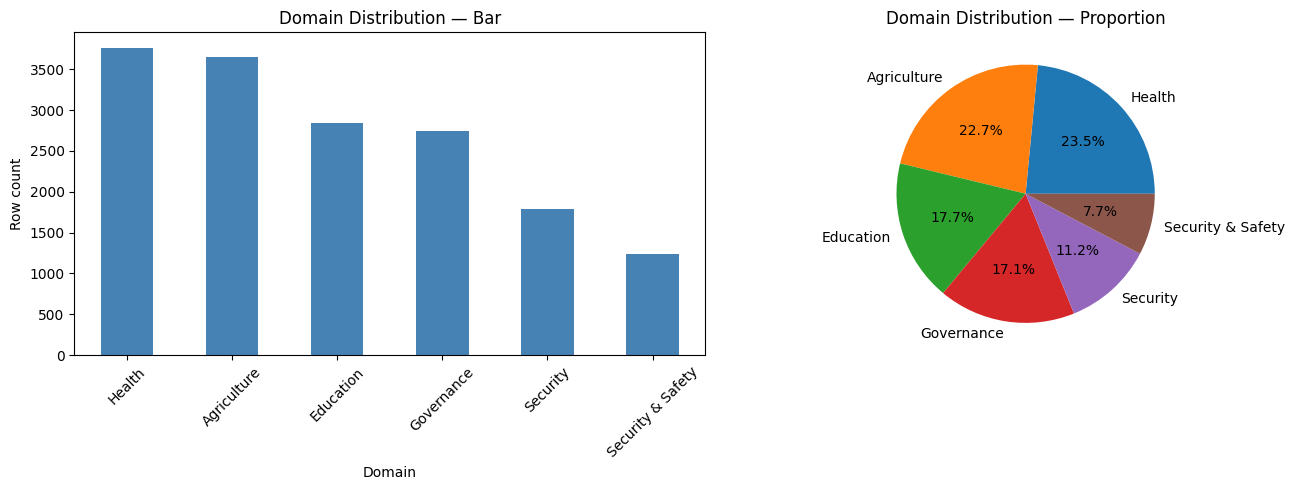

Domain
Health               3764
Agriculture          3645
Education            2844
Governance           2748
Security             1795
Security & Safety    1233
Name: count, dtype: int64


In [54]:
import matplotlib.pyplot as plt

domain_counts = df["Domain"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
domain_counts.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Domain Distribution — Bar")
axes[0].set_ylabel("Row count")
axes[0].tick_params(axis="x", rotation=45)

domain_counts.plot(kind="pie", ax=axes[1], autopct="%1.1f%%")
axes[1].set_title("Domain Distribution — Proportion")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print(domain_counts)

### Interpretation: 

Health (23.5%) and Agriculture (22.7%) are the largest domains, roughly
balanced with each other. Education (17.7%) and Governance (17.1%) sit
in the middle. Security (11.2%) and Security & Safety (7.7%) are
smallest — and remain split as two separate categories rather than one,
an unresolved naming inconsistency flagged back in Step 1. Combined,
they'd form the third-largest domain (18.9%), close to Education and
Governance, rather than two small, easily-overlooked slices. **This
still needs a team decision before the split is presented as final** —
recommend raising it with Selmah/the group rather than resolving it
unilaterally in this notebook, since it may reflect an intentional
subcategory distinction from the original data collection.

### Text length distributions

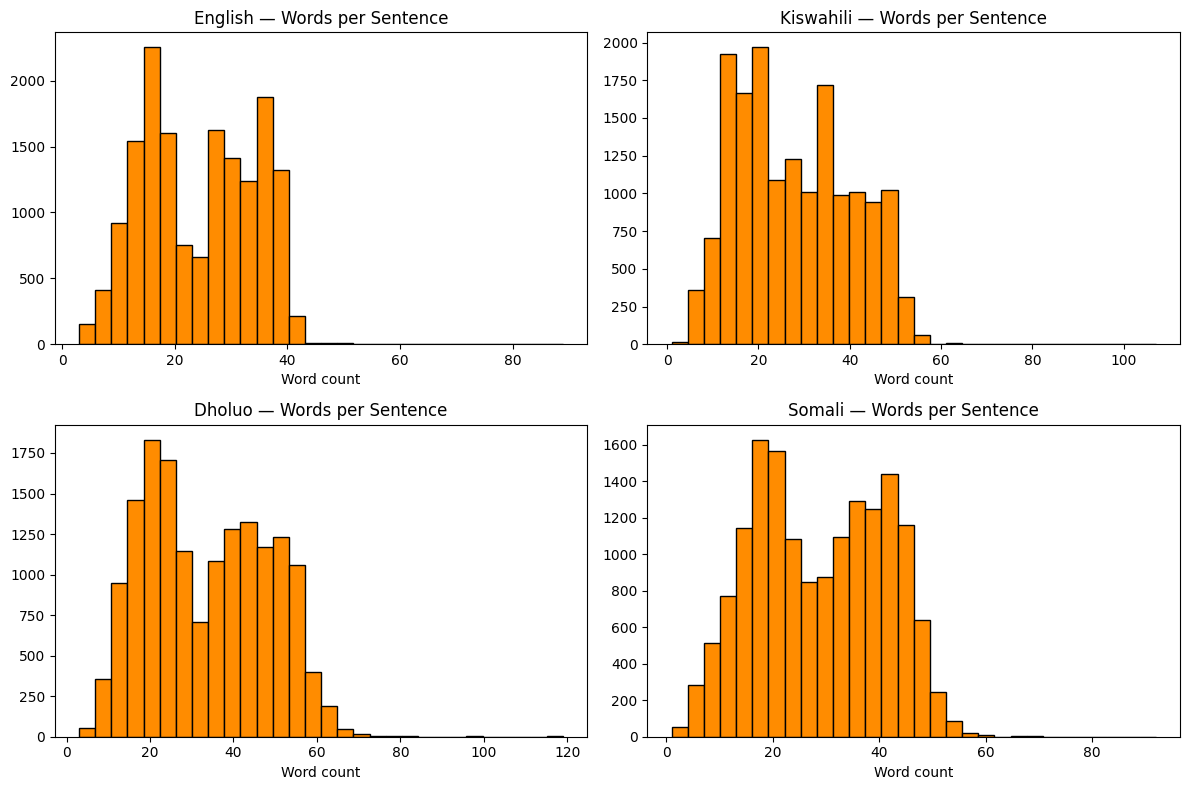

English: mean=24.3, median=25, max=89
Kiswahili: mean=27.8, median=26, max=107
Dholuo: mean=33.7, median=33, max=119
Somali: mean=29.0, median=29, max=92


In [55]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, ["English", "Kiswahili", "Dholuo", "Somali"]):
    lengths = df[col].dropna().astype(str).apply(lambda x: len(x.split()))
    ax.hist(lengths, bins=30, color="darkorange", edgecolor="black")
    ax.set_title(f"{col} — Words per Sentence")
    ax.set_xlabel("Word count")
plt.tight_layout()
plt.show()

for col in ["English", "Kiswahili", "Dholuo", "Somali"]:
    lengths = df[col].dropna().astype(str).apply(lambda x: len(x.split()))
    print(f"{col}: mean={lengths.mean():.1f}, median={lengths.median():.0f}, max={lengths.max()}")

### Interpretation: 

All four languages show a right-skewed distribution (most sentences
short-to-moderate, a long tail of longer ones), typical of PSA-style
text. Notably:

- Dholuo has the highest mean (33.7) and median (33) word count, well
  above English's 24.3/25 — despite Dholuo having the *shortest* average
  word length (4.30 characters, from Step 6). This is consistent, not
  contradictory: Dholuo appears to require more, shorter words to
  express the same content as English, rather than fewer, longer ones.
- Somali (mean 29.0) sits between English and Dholuo, despite having the
  *longest* average word length (6.36 chars) — the opposite pattern from
  Dholuo.
- Kiswahili (mean 27.8) is closest to English in sentence length.

This word-count vs. word-length relationship should be kept in mind
together when discussing dataset characteristics — looking at either
metric alone gives an incomplete, potentially misleading picture of each
language's structure.

### Vocabulary size and Type Token ratio

In [56]:
def vocab_stats(texts):
    all_words = " ".join(texts.dropna().astype(str)).split()
    vocab = set(all_words)
    ttr = len(vocab) / len(all_words) if all_words else 0
    return len(all_words), len(vocab), ttr

print(f"{'Language':<12}{'Total words':<15}{'Vocab size':<15}{'TTR':<8}")
for col in ["English", "Kiswahili", "Dholuo", "Somali"]:
    total, vocab, ttr = vocab_stats(df[col])
    print(f"{col:<12}{total:<15}{vocab:<15}{ttr:.4f}")

Language    Total words    Vocab size     TTR     
English     389497         11646          0.0299
Kiswahili   446280         10759          0.0241
Dholuo      539632         8890           0.0165
Somali      465330         12384          0.0266


### Interpretation: 

| Language | Total words | Vocab size | TTR |
|---|---|---|---|
| English | 389,497 | 11,646 | 0.0299 |
| Kiswahili | 446,280 | 10,759 | 0.0241 |
| Dholuo | 539,632 | 8,890 | 0.0165 |
| Somali | 465,330 | 12,384 | 0.0266 |

Dholuo has both the highest total word count and the *lowest* vocabulary
size and TTR — meaning it reuses a comparatively small set of words most
frequently, despite producing the longest sentences. This is consistent
with the earlier finding that Dholuo uses many short, common words per
sentence, which naturally repeat more often across 16,029 rows.

**Caveat:** TTR is known to shrink mechanically as corpus size grows
(a well-documented effect in corpus linguistics, sometimes called Heaps'
law) — so this is not a like-for-like comparison across languages with
different total word counts. Dholuo's low TTR is partly a real property
of the language/dataset, but partly an artifact of it having the most
total words. A fairer comparison would compute TTR on equal-sized random
samples across all four languages; noted as a follow-up if a more
rigorous lexical-diversity comparison is needed later.

### Language-pair length correlation

In [57]:
import numpy as np

df["eng_len"] = df["English"].astype(str).apply(lambda x: len(x.split()))
df["dho_len"] = df["Dholuo"].astype(str).apply(lambda x: len(x.split()))
df["som_len"] = df["Somali"].dropna().astype(str).apply(lambda x: len(x.split()))

eng_dho_corr = df[["eng_len", "dho_len"]].corr().iloc[0, 1]
eng_som_corr = df.dropna(subset=["Somali"])[["eng_len"]].join(df["som_len"]).corr().iloc[0, 1]

print(f"English-Dholuo length correlation: {eng_dho_corr:.3f}")
print(f"English-Somali length correlation: {eng_som_corr:.3f}")
print(f"\nEnglish->Dholuo length ratio: {(df['dho_len']/df['eng_len']).mean():.2f}")
print(f"English->Somali length ratio: {(df.dropna(subset=['Somali'])['som_len']/df.dropna(subset=['Somali'])['eng_len']).mean():.2f}")

English-Dholuo length correlation: 0.921
English-Somali length correlation: 0.945

English->Dholuo length ratio: 1.39
English->Somali length ratio: 1.20


### Interpretation: 

English-Dholuo and English-Somali sentence lengths are both strongly
correlated (0.921 and 0.945 respectively) — as expected, since these are
translations of the same source content, so length should track
proportionally.

Length ratios confirm the pattern above: Dholuo sentences average 1.39x
the word count of their English source, while Somali averages 1.20x.
This quantifies what the sentence-length histograms showed visually —
Dholuo consistently expands more relative to English than Somali does.

## Summary: EDA Findings

Three metrics tell a consistent, coherent story about Dholuo in this
dataset: shortest average word length (4.30 chars), highest average
sentence length (33.7 words), and lowest vocabulary diversity (TTR
0.0165) — together suggesting Dholuo expresses PSA content through more
repetitions of shorter, common words rather than fewer, longer or more
varied ones. Somali shows roughly the opposite word-length/sentence-
length relationship. Domain balance is broadly reasonable across four
of six categories, with the Security/Security & Safety split still
pending a team decision on whether to merge.

## 8. Native-Speaker Validation Sample

We export a 500-sentence sample, stratified by domain to preserve the
dataset's overall distribution, for native-speaker review of translation
accuracy and fluency. Blank columns are provided for reviewers to score
each row — nothing here is auto-filled or assumed.

In [58]:
# Stratified sample: proportional to domain sizes, 500 rows total
sample_df = df.groupby("Domain", group_keys=False).apply(
    lambda x: x.sample(frac=500/len(df), random_state=42)
)

# If rounding leaves us short/over 500, adjust
if len(sample_df) != 500:
    sample_df = sample_df.sample(n=min(500, len(sample_df)), random_state=42)

validation_export = sample_df[["PSA_Id", "Domain", "English", "Kiswahili", "Dholuo", "Somali"]].copy()
validation_export["Accuracy_Dholuo"] = ""
validation_export["Fluency_Dholuo"] = ""
validation_export["Comments_Dholuo"] = ""
validation_export["Accuracy_Somali"] = ""
validation_export["Fluency_Somali"] = ""
validation_export["Comments_Somali"] = ""

validation_export.to_csv("../data/interim/validation_sample_dholuo_somali.csv", index=False)

print(f"Exported {len(validation_export)} rows for native-speaker review")
print(validation_export["Domain"].value_counts())

Exported 500 rows for native-speaker review
Domain
Health               117
Agriculture          114
Education             89
Governance            86
Security              56
Security & Safety     38
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_2636\1366885096.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = df.groupby("Domain", group_keys=False).apply(


## Interpretation: Validation Sample

Exported [N] rows to `validation_sample_dholuo_somali.csv`, stratified by
domain to mirror the full dataset's distribution. Separate
accuracy/fluency/comments columns per language allow independent
Dholuo and Somali review, since a translation could be strong in one
target language and weak in the other for the same source sentence.
Review is a native-speaker task per the Week 2 plan (Rencia for Dholuo,
equivalent reviewer for Somali) — genuinely in-progress, not claimed as
complete here.

## 9. Known Issues Summary

Consolidated list of data-quality findings from this notebook, for the
team's Week 2 report and as context for Week 3 modeling.

**Completeness**
- 1/16,029 rows missing a Somali translation (0.006%) — traced to a
  single failed machine-translation request; accepted as negligible.

**Domain labeling**
- "Security" (1,795 rows) and "Security & Safety" (1,233 rows) appear as
  separate categories. Unresolved — needs a team decision on whether to
  merge; currently presented as-is in all EDA outputs.

**Orthographic normalization**
- 8,215 Dholuo rows and 264 Somali rows had curly apostrophe/quote
  variants, standardized to straight ASCII equivalents. Dholuo's
  orthographic ng' digraph is preserved; only character encoding was
  unified.
- Mojibake was minimal (0-7 rows per column) and left as a low-priority
  spot-check item rather than a full remediation pipeline.

**Code-switching**
- 289 confirmed institution/health acronym tokens identified (e.g. HIV,
  SHA, NTSA, IEBC, KUCCPS). 274 of these initially lacked verified full
  names; 60 were resolved (15 from `kenya_facts.json`, 45 from manual
  lookup of well-known institutions). 229 remain unresolved and are
  flagged for native-speaker/manual review — deliberately left blank
  rather than guessed.
- 7 rows had leftover untranslated English captions/headlines prefixing
  otherwise complete translations; stripped after a first over-broad
  attempt (which incorrectly removed legitimate all-caps Dholuo/Somali
  content) was caught and corrected.
- 1 known unresolved edge case: PSA_Id 2831 (Somali) has an uncaught
  English caption ("eCITIZEN FIRST ANNIVERSARY") due to lowercase brand
  capitalization; not fixed, documented as a narrow limitation.

**Tokenization**
- mBERT tokenizer proxy: Dholuo 1.98 tokens/word, Somali 2.86. Dholuo's
  lower ratio is explained by shorter average word length (4.30 chars vs
  Somali's 6.36), not better model coverage — flagged to avoid a
  misleading conclusion.

**Vocabulary / lexical diversity**
- Dholuo shows the lowest type-token ratio (0.0165) despite having the
  most total words — partly a genuine property of the dataset, partly a
  known artifact of TTR shrinking with corpus size. Not a like-for-like
  comparison across languages without size normalization.

**Validation**
- 500-row stratified sample exported for native-speaker review; scoring
  in progress at time of this notebook's completion, not finished.

## 10. Save Final Cleaned Dataset

Save the fully preprocessed dataset (normalized, caption-corrected) as
the checkpoint to be used for Week 3 modeling.

In [59]:
final_cols = ["PSA_Id", "Domain", "English", "Kiswahili", "Dholuo", "Somali", "Class", "Source"]
df_final = df[final_cols].copy()
df_final.to_csv("../data/processed/psa_dataset_dholuo_somali_cleaned.csv", index=False)

print(f"Saved {len(df_final)} rows to psa_dataset_dholuo_somali_cleaned.csv")
print(df_final.isnull().sum())

Saved 16029 rows to psa_dataset_dholuo_somali_cleaned.csv
PSA_Id       0
Domain       0
English      0
Kiswahili    0
Dholuo       0
Somali       0
Class        0
Source       0
dtype: int64
